In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [4]:
exp_name = 'default_002'

gsnn_res = pd.read_csv(f'../../workflow_outputs/gsnn-mds/exp/{exp_name}/gsnn/stratified_results.csv')
nn_res = pd.read_csv(f'../../workflow_outputs/gsnn-mds/exp/{exp_name}/nn/stratified_results.csv')
res = gsnn_res.merge(nn_res, on='drug_combination', suffixes=('_gsnn', '_nn'))
res = res.assign(is_comb = [' + ' in x for x in res.drug_combination])

In [5]:
res[lambda x: x.drug_combination == 'overall'][['spearman_r_gsnn', 'spearman_r_nn']]

,spearman_r_gsnn,spearman_r_nn
142,0.659501,0.606372


In [6]:
res[lambda x: x.drug_combination == 'overall'][['r2_gsnn', 'r2_nn']]

,r2_gsnn,r2_nn
142,0.424526,0.363528


In [7]:
res[lambda x: x.drug_combination == 'overall'][['mse_gsnn', 'mse_nn']]

,mse_gsnn,mse_nn
142,0.454165,0.502304


In [8]:
# remove "overall"
res = res[res['drug_combination'] != 'overall']

# remove drugs that have less than 10 samples 
#res = res[res['n_samples_gsnn'] >= 10]

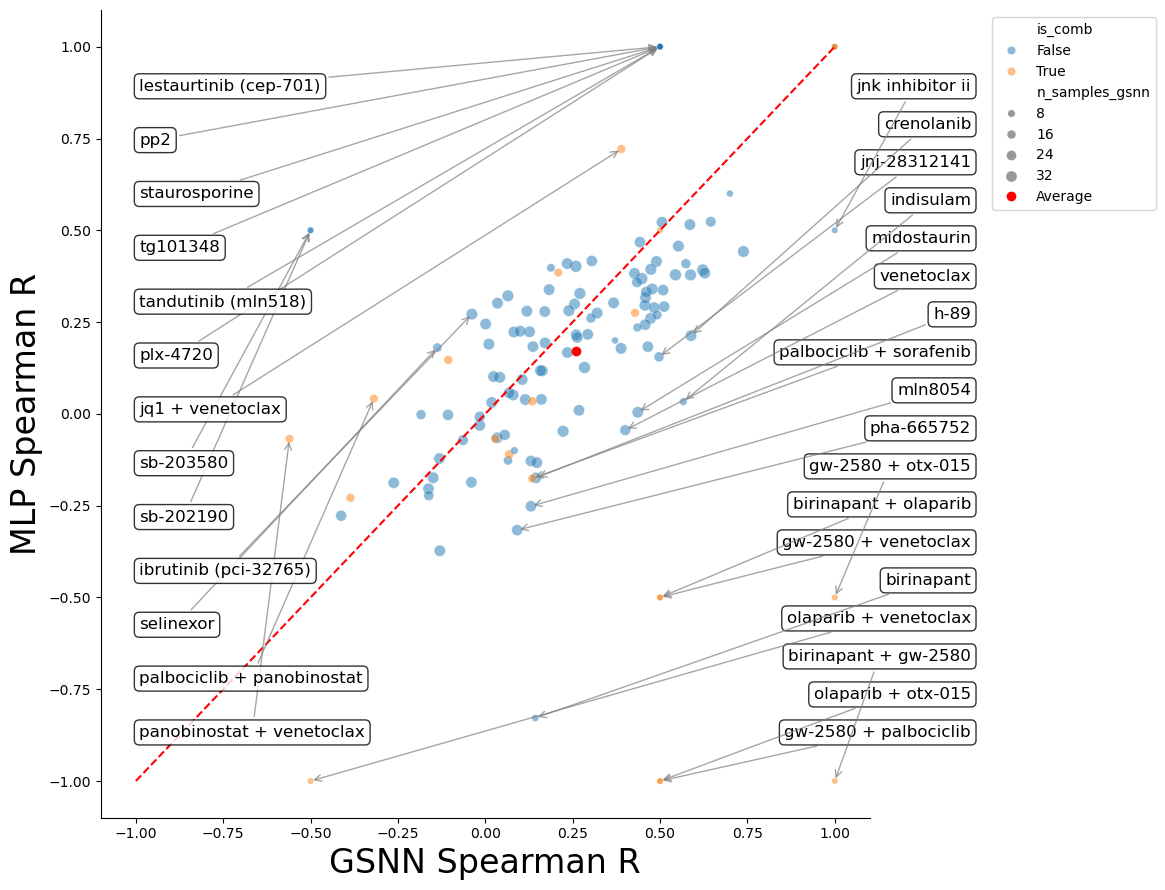

In [9]:
plt.figure(figsize=(12, 9)) 
sbn.scatterplot(data=res, x='spearman_r_gsnn', y='spearman_r_nn', alpha=0.5, hue='is_comb', size='n_samples_gsnn')
plt.plot([-1, 1], [-1, 1], 'r--')
plt.xlabel('GSNN Spearman R', fontsize=24)
plt.ylabel('MLP Spearman R', fontsize=24)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# label outliers (difference > 0.4)
outliers = res[abs(res['spearman_r_gsnn'] - res['spearman_r_nn']) > 0.3]

# Get plot limits for positioning
xlim = plt.xlim()
ylim = plt.ylim()

# Split outliers based on which side of diagonal they're on
# Left side: GSNN performs better (upper left triangle)
left_outliers = outliers[outliers['spearman_r_gsnn'] < outliers['spearman_r_nn']].sort_values('spearman_r_nn')
# Right side: NN performs better (lower right triangle)  
right_outliers = outliers[outliers['spearman_r_gsnn'] > outliers['spearman_r_nn']].sort_values('spearman_r_nn')

# Position labels on the left side
left_x = xlim[0] + (xlim[1] - xlim[0]) * 0.05  # 5% from left edge
for i, (idx, row) in enumerate(left_outliers.iterrows()):
    label_y = ylim[0] + (ylim[1] - ylim[0]) * (0.1 + 0.8 * i / max(1, len(left_outliers)-1))
    plt.annotate(f'{row["drug_combination"]}', 
                xy=(row['spearman_r_gsnn'], row['spearman_r_nn']),
                xytext=(left_x, label_y),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7),
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                fontsize=12)

# Position labels on the right side  
right_x = xlim[1] - (xlim[1] - xlim[0]) * 0.05 + 0.4 # 5% from right edge
for i, (idx, row) in enumerate(right_outliers.iterrows()):
    label_y = ylim[0] + (ylim[1] - ylim[0]) * (0.1 + 0.8 * i / max(1, len(right_outliers)-1))
    plt.annotate(f'{row["drug_combination"]}', 
                xy=(row['spearman_r_gsnn'], row['spearman_r_nn']),
                xytext=(right_x, label_y),
                arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7),
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                fontsize=12,
                ha='right')

#  average  
plt.plot(res.spearman_r_gsnn.mean(), res.spearman_r_nn.mean(), 'o', color='red', label='Average')

# put legend outside the plot 
plt.legend(bbox_to_anchor=(1.15, 1), loc='upper left')

plt.tight_layout() 
plt.show() 

In [10]:
res[lambda x: x.drug_combination == 'venetoclax']

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb
103,venetoclax,29,0.115603,0.471847,0.500285,0.400493,29,-0.938545,0.115579,1.096595,-0.044335,False


In [11]:
res[lambda x: x.drug_combination.str.startswith('azacitidine')]

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb


In [12]:
res[lambda x: x.n_samples_gsnn > 20].sort_values('spearman_r_gsnn', ascending=False).head(10)

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb
85,trametinib (gsk1120212),36,0.450015,0.690795,0.420467,0.738739,36,0.209655,0.468927,0.604224,0.442214,False
101,jq1,27,0.412431,0.648505,0.147145,0.645299,27,0.291404,0.542107,0.177454,0.523199,False
75,selumetinib (azd6244),34,0.285399,0.545802,0.719481,0.628161,34,0.143920,0.421049,0.861926,0.383375,False
16,dasatinib,38,0.330169,0.603463,0.517065,0.622278,38,0.089577,0.355148,0.702786,0.391837,False
14,crenolanib,34,0.168647,0.491152,0.193417,0.588694,34,-0.504019,0.262379,0.349915,0.212834,False
6,axitinib (ag-013736),36,0.329342,0.606237,0.274857,0.587387,36,0.031165,0.376504,0.397059,0.378378,False
50,motesanib (amg-706),34,0.289615,0.556644,0.353310,0.585511,34,0.173652,0.436610,0.410984,0.515513,False
113,otx-015,23,0.348308,0.654684,0.348536,0.574111,23,0.144394,0.411143,0.457592,0.409091,False
65,rapamycin,35,0.281682,0.534097,0.409410,0.552661,35,0.081154,0.372801,0.523702,0.456863,False
78,sunitinib,38,0.196927,0.475476,0.274513,0.544151,38,-0.017720,0.317589,0.347886,0.378707,False


In [13]:
res[lambda x: x.n_samples_gsnn > 25].sort_values('r2_gsnn', ascending=False).head(25)

,drug_combination,n_samples_gsnn,r2_gsnn,pearson_r_gsnn,mse_gsnn,spearman_r_gsnn,n_samples_nn,r2_nn,pearson_r_nn,mse_nn,spearman_r_nn,is_comb
85,trametinib (gsk1120212),36,0.450015,0.690795,0.420467,0.738739,36,0.209655,0.468927,0.604224,0.442214,False
101,jq1,27,0.412431,0.648505,0.147145,0.645299,27,0.291404,0.542107,0.177454,0.523199,False
16,dasatinib,38,0.330169,0.603463,0.517065,0.622278,38,0.089577,0.355148,0.702786,0.391837,False
6,axitinib (ag-013736),36,0.329342,0.606237,0.274857,0.587387,36,0.031165,0.376504,0.397059,0.378378,False
50,motesanib (amg-706),34,0.289615,0.556644,0.353310,0.585511,34,0.173652,0.436610,0.410984,0.515513,False
75,selumetinib (azd6244),34,0.285399,0.545802,0.719481,0.628161,34,0.143920,0.421049,0.861926,0.383375,False
65,rapamycin,35,0.281682,0.534097,0.409410,0.552661,35,0.081154,0.372801,0.523702,0.456863,False
82,tivozanib (av-951),33,0.252934,0.505071,0.517008,0.508899,33,0.023374,0.309609,0.675875,0.337094,False
102,lenvatinib,28,0.248562,0.500136,0.503333,0.434045,28,0.063085,0.333011,0.627570,0.358511,False
0,17-aag (tanespimycin),33,0.244155,0.583402,0.244088,0.505682,33,0.137810,0.508381,0.278430,0.522059,False


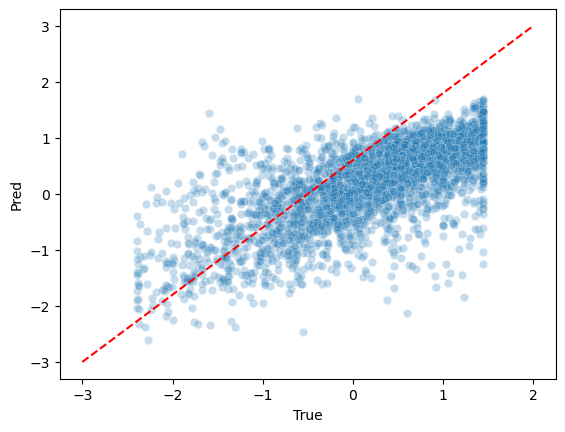

In [14]:
gsnn_preds = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/gsnn/predictions.csv') 
nn_preds = pd.read_csv('../../workflow_outputs/gsnn-mds/exp/default/nn/predictions.csv') 

plt.figure() 
sbn.scatterplot(data=gsnn_preds, x='y_true', y='y_pred', alpha=0.25)
plt.plot([-3, 2], [-3, 3], 'r--')
plt.xlabel('True')
plt.ylabel('Pred')
plt.show() 

In [15]:
gsnn_preds.shape

(3503, 2)

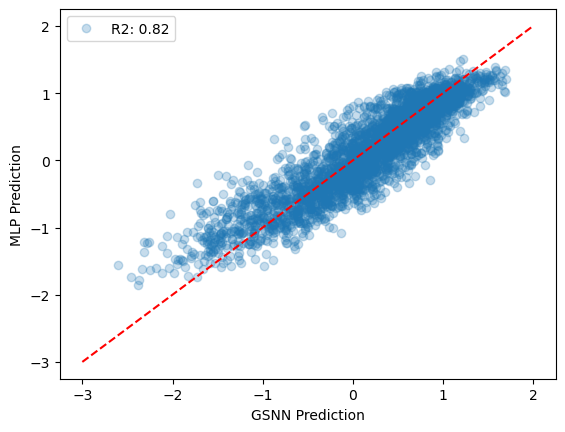

In [16]:
from sklearn.metrics import r2_score
r2 = r2_score(gsnn_preds.y_pred, nn_preds.y_pred)

plt.figure() 
plt.plot(gsnn_preds.y_pred, nn_preds.y_pred, 'o', alpha=0.25, label=f'R2: {r2:.2f}')
plt.plot([-3, 2], [-3, 2], 'r--')
plt.xlabel('GSNN Prediction')
plt.ylabel('MLP Prediction')
plt.legend()
plt.show() 

In [17]:
pred_mean = (gsnn_preds.y_pred + nn_preds.y_pred) / 2 

r_nn = np.corrcoef(nn_preds.y_pred, nn_preds.y_true)[0, 1]
r_gsnn = np.corrcoef(gsnn_preds.y_pred, gsnn_preds.y_true)[0, 1]
r_mean = np.corrcoef(pred_mean, gsnn_preds.y_true)[0, 1] 

print(f'NN R: {r_nn:.2f}, GSNN R: {r_gsnn:.2f}, Mean R: {r_mean:.2f}')

NN R: 0.70, GSNN R: 0.71, Mean R: 0.72
